In [1]:
# Python ≥3.5 is required
import sys

# Scikit-Learn ≥0.20 is required
import sklearn

# TensorFlow ≥2.0 is required
import tensorflow as tf
from tensorflow import keras


# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
plt.rc('font', size=12) 
plt.rc('figure', figsize = (12, 5))

# Settings for the visualizations
#import seaborn as sns
#sns.set_style("whitegrid")
#sns.set_context("notebook", font_scale=1, rc={"lines.linewidth": 2,'font.family': [u'times']})

import pandas as pd
pd.set_option('display.max_rows', 25)
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_colwidth', 50)

# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

2025-12-29 22:37:50.825451: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767047871.072589     146 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767047871.160828     146 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767047871.788533     146 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767047871.788594     146 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767047871.788597     146 computation_placer.cc:177] computation placer alr

In [2]:
# data augmentation
from skimage.transform import rescale, resize, downscale_local_mean
from functools import partial
from sklearn.datasets import load_sample_image
from functools import partial

import imageio
from skimage import transform,io
import imageio.v2 as imageio
import matplotlib.pyplot as plt

In [3]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPUs disponibles:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.19.0
GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


# Descarga de datos de train y test

Preparamos todos los datos a usar y separamos train en train y validation. Las imagenes originales tienen un tamaño de 158 * 158, nosotros reduciremos este tamaño a 64*64 para ahorrarnos calculos. Las imagenes con 64 * 64 pixeles son suficientemente grandes para poder distinguir a las personas que hay

## Datos de train

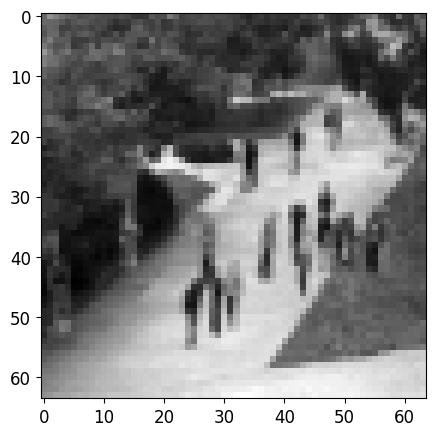

label: 20.0


In [4]:
# Tamaño de imagen a usar
im_size = 64


data_txt = '/kaggle/input/ml-ub-project-4-learning-to-count-2025-26/train.txt'
df_train = pd.read_csv(data_txt,sep=' ',header=None)

data_dir = '/kaggle/input/ml-ub-project-4-learning-to-count-2025-26'
N = df_train.shape[0]
X = np.zeros((N, im_size, im_size, 1)) # 1 canal , grayscale 
y = np.zeros((N))
cont =0

for ind, item in df_train.iterrows():
    im       = imageio.imread(data_dir + item[0])
    small_im = transform.resize(im, (im_size, im_size), mode='symmetric')
    X[cont, :, :, 0] = small_im
    y[cont] = item[1]
    cont+=1
    
plt.imshow(X[0, :,:],cmap='gray')
plt.show()
print("label:", y[0])

## Separar train y validation

Separamos un 20% del dataset original de train para poder tener validation. Hacemos este paso antes de la exploración de datos

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=66
)


# Exploración de datos

Ahora que tenemos los datos de train separados de validation empezamos a ver el dataset para buscar posibles desbalances y ver que datos tenemos antes de empezar con el modelo

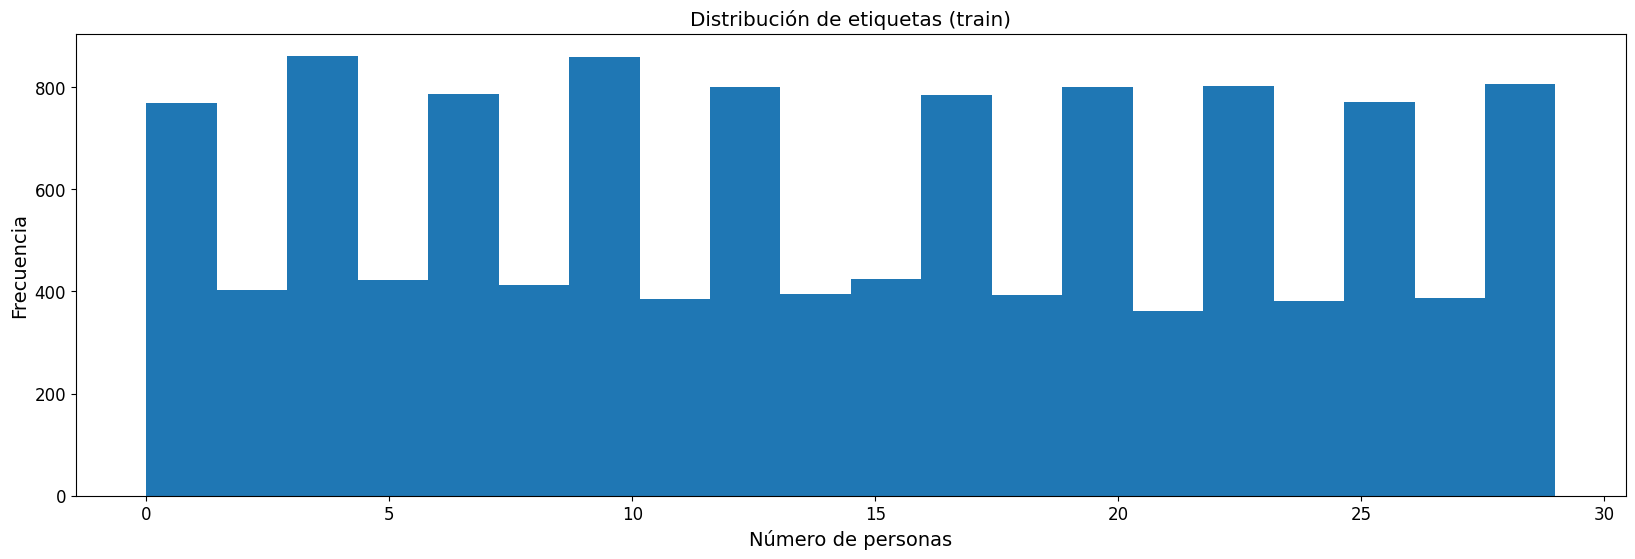

Min personas: 0.0
Max personas: 29.0
Media: 14.366833333333334


In [6]:
# VER LA DISTRIBUCIÓN DE ETIQUETAS

plt.figure(figsize=(20,6))
plt.hist(y_train, bins=20)
plt.xlabel("Número de personas")
plt.ylabel("Frecuencia")
plt.title("Distribución de etiquetas (train)")
plt.show()

print("Min personas:", y_train.min())
print("Max personas:", y_train.max())
print("Media:", y_train.mean())


In [8]:
# VER EL RANGO DE VALORES DE UNA IMAGEN
idx_min = np.argmin(y_train)
idx_max = np.argmax(y_train)

print(f"Valor maximo { X_train[idx_min, :, :, 0].max() } valor minimo {X_train[idx_min, :, :, 0].min()} ")

Valor maximo 0.9502445742350828 valor minimo 0.06687886053358075 


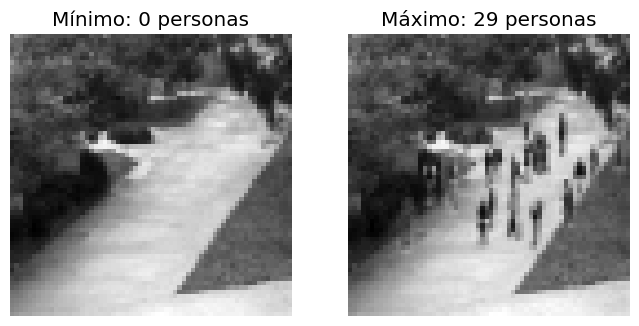

In [9]:
# VER LA IMAGEN CON MAYOR Y MENOR CANTIDAD DE PERSONAS
idx_min = np.argmin(y_train)
idx_max = np.argmax(y_train)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(X_train[idx_min, :, :, 0], cmap='gray')
plt.title(f"Mínimo: {int(y_train[idx_min])} personas")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(X_train[idx_max, :, :, 0], cmap='gray')
plt.title(f"Máximo: {int(y_train[idx_max])} personas")
plt.axis('off')

plt.show()


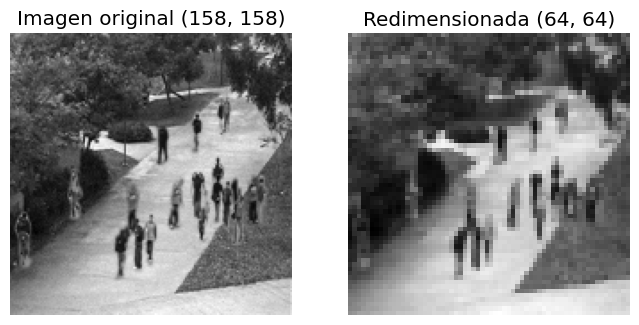

In [10]:
# imagen original
im_path = data_dir + df_train.iloc[0][0]
im_orig = imageio.imread(im_path)

im_resized = transform.resize(im_orig, (im_size, im_size))

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(im_orig, cmap='gray')
plt.title(f"Imagen original {im_orig.shape}")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(im_resized, cmap='gray')
plt.title(f"Redimensionada {im_resized.shape}")
plt.axis('off')

plt.show()


## Conclusiones de la exploración de datos de train (sin validation)

- Durante la exploración de datos se observa que la distribución de las etiquetas es aproximadamente uniforme entre 0 y 29 personas, por lo que no existe un problema de desbalance en el conjunto de entrenamiento.

- Visualmente, las imágenes son el mismo camino de un parque, variando únicamente el número de personas presentes en la escena. Esto implica que el fondo es altamente consistente entre muestras, mientras que la variabilidad del problema se concentra en la densidad y distribución espacial de las personas. Al comparar las imágenes originales con su versión redimensionada a 64×64 píxeles, se aprecia una pérdida de detalle fino, pero se conserva la estructura global de la escena y la presencia de siluetas humanas, lo cual resulta suficiente para un enfoque de conteo. Estas observaciones sugieren que el problema se aborda mejor como una tarea de regresión basada en patrones de densidad visual, y que existe un riesgo de sobreajuste al fondo, lo que justifica el uso de técnicas de regularización y aumento de datos para romper la dependencia excesiva del fondo y obligar al modelo a fijarse en patrones más robustos

# Data augmentation

La gracia del data augmentation no es tener millones de imagenes diferentes, sino romper la dependencia del fondo y forzar al modelo a aprender patrones robustos.

En este caso haremos 2 datasets diferentes, uno con data augmentation y otro sin, para compararlos.

Muy importante tener en cuenta que validation nunca tendra data augmentation, solo sirve para entrenar , no para verificar.

In [11]:
# TRAIN SIN DATA AUGMENTATION

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen_no_aug = ImageDataGenerator()

train_generator_no_aug = datagen_no_aug.flow(
    X_train,
    y_train,
    batch_size=32,
    shuffle=True
)


In [12]:
# TRAIN CON DATA AUGMENTATION


datagen_aug = ImageDataGenerator(
    width_shift_range=0.05,     # pequeños desplazamientos horizontales
    height_shift_range=0.05,    # pequeños desplazamientos verticales
    zoom_range=0.1,             # zoom suave
    horizontal_flip=True        # simetría horizontal 
)

train_generator_aug = datagen_aug.flow(
    X_train,
    y_train,
    batch_size=32,
    shuffle=True
)


In [13]:
# VALIDATION SIN AUGMENTATION 

# no aumentamos , es decir, es el mismo dataset anterior. 
# Esto sirve para tener el mismo formato que el train

val_datagen = ImageDataGenerator()

val_generator = val_datagen.flow(
    X_val,
    y_val,
    batch_size=32,
    shuffle=False
)


### Ejemplos randoms del data aug

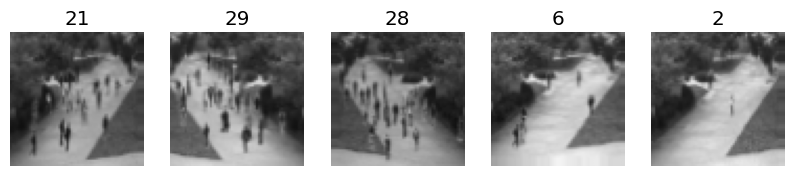

In [15]:
import matplotlib.pyplot as plt

batch_X, batch_y = next(train_generator_aug)

plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(batch_X[i].squeeze(), cmap='gray', vmin=0, vmax=1)
    plt.title(f"{int(batch_y[i])}")
    plt.axis('off')

plt.show()


## Explicación data augmentation aplicado

Como las imágenes presentan un fondo altamente consistente, se ha aplicado una estrategia de aumento de datos moderada únicamente sobre el conjunto de entrenamiento. El aumento incluye pequeños desplazamientos, variaciones suaves de escala y simetría horizontal, con el objetivo de reducir el sobreajuste al fondo y fomentar el aprendizaje de patrones más robustos relacionados con la densidad de personas. Para evaluar el impacto del aumento de datos, se entrenará el mismo modelo tanto con como sin aumento, manteniendo fijo el conjunto de validación.

# Creación del modelo

## Modelo normal a usar

### Criteris per dissenyar l’arquitectura d’una xarxa

La arquitectura del modelo se ha diseñado priorizando la simplicidad y evitando complejidad innecesaria. Dado que las imágenes presentan un encuadre fijo y una variación limitada al número de personas, se ha optado por una red convolucional pequeña con pocas capas, suficiente para capturar los patrones relevantes sin riesgo elevado de sobreajuste.

### Com decidir el número de neurones a la capa d’entrada?

El número de neuronas de la capa de entrada viene determinado por el tamaño de las imágenes de entrada, que en este caso son imágenes en escala de grises de tamaño 64×64 píxeles. Este tamaño se ha escogido para reducir el coste computacional manteniendo la información visual necesaria para el conteo de personas.

### Com decidir el número de capes ocultes i el número de neurones a les capes ocultes?

Se utilizan dos capas convolucionales, ya que este número permite extraer características visuales de distinta complejidad sin introducir un modelo excesivamente profundo. Tras las capas convolucionales, se emplea una única capa densa de 32 neuronas, elegida como compromiso entre capacidad de representación y simplicidad del modelo.

### Com decidir el número de neurones a la capa de sortida?

La capa de salida contiene una única neurona, ya que el objetivo del modelo es predecir un único valor numérico: el número de personas presentes en la imagen. Esta configuración es la adecuada para un problema de regresión.

### Com escollir la funció d’activació a les capes ocultes?

En las capas ocultas se utiliza la función de activación ReLU, ya que permite introducir no linealidad en el modelo y facilita un entrenamiento estable y eficiente. Además, reduce el riesgo de problemas como el gradiente minvante en redes profundas.

### Com escollir la funció d’activació a la capa de sortida?

En la capa de salida se emplea una función de activación lineal, ya que el problema es de regresión y se requiere predecir un valor continuo. El uso de una activación lineal permite al modelo producir cualquier valor real sin restricciones.

### Què és un filtre? Quin número de filtres he de posar?

Un filtro es el resultado de aplicar un kernel convolucional sobre la imagen y permite detectar un patrón visual específico, como bordes o agrupaciones de personas. En este modelo se utilizan 16 filtros en la primera capa convolucional para detectar características simples y 64 filtros en la segunda capa para capturar patrones más complejos relacionados con la densidad de personas. Este aumento progresivo del número de filtros permite mejorar la capacidad de representación del modelo sin aumentar excesivamente su complejidad.

### Regularització del model

La regularización consiste en introducir ruido durante el entrenamiento para evitar que el modelo memorice los datos y favorecer el aprendizaje de patrones generales. En este caso no se han utilizado técnicas como Dropout o normalización adicional, ya que las imágenes del dataset son muy similares entre sí y estas técnicas provocan una sobrerregularización que empeora el rendimiento del modelo. 

### Per què és un problema de regressió?

Este problema se plantea como un problema de regresión porque el objetivo del modelo es predecir una cantidad numérica, concretamente el número de personas presentes en cada imagen. No se trata de asignar una imagen a una clase concreta, como ocurriría en un problema de clasificación, sino de estimar un valor que puede tomar distintos valores enteros según la escena. Por este motivo, el modelo utiliza una única neurona en la capa de salida con activación lineal y se entrena minimizando el error cuadrático medio. Además, la métrica RMSE permite evaluar el error medio en las mismas unidades que la variable objetivo, facilitando la interpretación de los resultados.


### Problema del gradient minvant (vanishing gradient) i estratègies per a resoldre’l

El problema del gradiente minvante aparece cuando, durante el entrenamiento, los gradientes que llegan a las primeras capas de la red son muy pequeños y el modelo deja de aprender correctamente. En este proyecto no se ha observado este problema, ya que la red es poco profunda y utiliza funciones de activación ReLU, que ayudan a mantener gradientes estables. En general, este problema se puede mitigar utilizando activaciones adecuadas, una inicialización correcta de los pesos, normalización intermedia o evitando redes innecesariamente profundas.

### Estratègies per evitar el sobreajust en xarxes neuronals

Para evitar el sobreajuste, se han considerado distintas estrategias como el uso de early stopping, la regularización mediante Dropout y el aumento de datos. El early stopping se ha utilizado para detener el entrenamiento cuando el error de validación deja de mejorar, evitando que el modelo memorice los datos de entrenamiento. Otras técnicas, como Dropout o data augmentation, se han probado, pero en este caso concreto han provocado una sobrerregularización debido a la similitud entre las imágenes, empeorando el rendimiento del modelo.

### Simplificació de models

La simplificación del modelo consiste en reducir su complejidad manteniendo un rendimiento similar. En este proyecto se han comparado distintas versiones del modelo, reduciendo el número de filtros o neuronas para analizar el impacto en el error de validación. Estas comparaciones permiten evaluar si una arquitectura más compleja está justificada o si un modelo más simple puede ofrecer resultados similares. En algunos casos, la simplificación provoca un empeoramiento del rendimiento, lo que indica que la complejidad del modelo final está justificada.

In [51]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Dropout

def build_cnn(input_shape=(64,64,1)):
    """
    Arquitectura de la red neuronal convolucional (CNN):
    
    La red recibe como entrada imágenes en escala de grises de tamaño 64×64×1.
    Consta de dos capas convolucionales con activación ReLU y kernels de 3×3,
    cada una seguida de una capa de max pooling 2×2 para reducir la resolución
    espacial.
    
    La primera capa convolucional utiliza 16 filtros y la segunda 64 filtros,
    permitiendo extraer patrones visuales de distinta complejidad relacionados
    con la presencia y densidad de personas en la imagen.
    
    Tras las capas convolucionales, se aplica una capa Flatten y una capa densa
    de 32 neuronas con activación ReLU. La salida del modelo es una única neurona
    con activación lineal, adecuada para un problema de regresión.
    
    El modelo se entrena minimizando el error cuadrático medio (MSE) y se evalúa
    utilizando la raíz del error cuadrático medio (RMSE).

    Como regularizador NO usamos dropout, ya que empeora mucho el rendimiento

    """

    model = Sequential([ 
        Conv2D(16, (3,3), activation='relu', padding='same', input_shape=input_shape), 
        MaxPooling2D((2,2)), 
        
        Conv2D(64, (3,3), activation='relu', padding='same'), 
        MaxPooling2D((2,2)), 
        
        Flatten(), 
        Dense(32, activation='relu'), 
        #Dropout(0.2), 
        Dense(1, activation='linear') # problema de regresión 
    ]) 
        
    model.compile( 
        optimizer=Adam(learning_rate=1e-3), 
        loss='mse', 
        metrics=[tf.keras.metrics.RootMeanSquaredError()] ) 
    
    
    return model 
        
model = build_cnn() 
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 64, 64, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 32, 32, 64)     │         9,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 32)             │       524,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,793 (2.04 MB)

 Trainable params: 533,793 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

Modelo con 500.000 parametros

## Modelo más simple

La creación de este modelo sirve para poder ver si nuestro modelo tiene la complejidad necesaria para el problema o si estamos usando una red excesiva. El modelo simplificado reduce tanto el número de filtros como el tamaño de la capa densa, lo que disminuye significativamente el número total de parámetros. Lo compararemos con el anterior modelo para ver si hay mucha diferencia o si este modelo sirve por si solo.

Otras pruebas realizadas serian de quitar neuronas en la densa, pero menos de 16 baja mucho la eficacia del modelo, asi que hemos decidido no seguir por ese camino.


In [57]:
def build_simpler_cnn(input_shape=(64,64,1)):
    """
    modelo más simple ( quitando una capa ) para ver si tener un modelo mas complejo es necesario o no
    """
    model = Sequential([

        Conv2D(16, (3,3), activation='relu', padding='same', input_shape=input_shape), 
        MaxPooling2D((2,2)), 
        
        Conv2D(32, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),

        Flatten(),
        Dense(16, activation='relu'),
        #Dropout(0.1),
        Dense(1, activation='linear')
    ])

    model.compile(
        optimizer=Adam(1e-3),
        loss='mse',
        metrics=[tf.keras.metrics.RootMeanSquaredError()]
    )

    return model

model_simple = build_simpler_cnn()
model_simple.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 64, 64, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_18 (Flatten)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 16)             │       131,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 135,905 (530.88 KB)

 Trainable params: 135,905 (530.88 KB)

 Non-trainable params: 0 (0.00 B)

# Entrenamiento con y sin data augmentation

En esta seccion entrenamos 4 modelos para poder compararlos.

- modelo usando data augmentation
- modelo simple usando data augmentation
  
- modelo sin usar data augmentation
- modelo mas simple sin data augmentation

#### RMSE como métrica de evaluación

La métrica utilizada para evaluar el rendimiento de los modelos es el RMSE (Root Mean Squared Error), ya que permite medir el error medio de predicción en las mismas unidades que la variable objetivo, es decir, número de personas. El RMSE penaliza especialmente los errores grandes, lo que resulta adecuado en este problema, donde una diferencia elevada entre el valor real y la predicción supone un fallo relevante del modelo. Además, su interpretación es directa, facilitando la comparación entre distintas arquitecturas y configuraciones de entrenamiento.

Además, se utiliza early stopping como técnica de control del entrenamiento, que detiene el proceso cuando el error de validación deja de mejorar durante varias épocas consecutivas, evitando así el sobreajuste y seleccionando automáticamente el modelo con mejor capacidad de generalización.

## Modelo normal usando data augmentation

In [23]:
# CON DATA AUGMENTATION Y MODELO NORMAL

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_root_mean_squared_error',
    patience=5,
    restore_best_weights=True
)


modelo_normal_aug = build_cnn()

history_normal_aug = modelo_normal_aug.fit(
    train_generator_aug,
    validation_data=val_generator,
    epochs=50,          # el early stopping decidirá cuando parar
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 69.8639 - root_mean_squared_error: 8.2234 - val_loss: 32.0888 - val_root_mean_squared_error: 5.6647
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 13.1649 - root_mean_squared_error: 3.6280 - val_loss: 14.4502 - val_root_mean_squared_error: 3.8013
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 10.1431 - root_mean_squared_error: 3.1844 - val_loss: 24.3975 - val_root_mean_squared_error: 4.9394
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 8.6931 - root_mean_squared_error: 2.9480 - val_loss: 11.8571 - val_root_mean_squared_error: 3.4434
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 7.9897 - root_mean_squared_error: 2.8261 - val_loss: 22.1287 - val_root_mean_squared_error: 4.7041
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 7.8284 - root_mean_squared_error: 2.7959 - val_loss: 8.5120 - val_root_mean_squared_error: 2.9175
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━

## Modelo simple usando data augmentation

In [58]:
# CON DATA AUGMENTATION CON MODELO SIMPLE

early_stop = EarlyStopping(
    monitor='val_root_mean_squared_error',
    patience=5,
    restore_best_weights=True
)

modelo_simple_aug = build_simpler_cnn()

history_simple_aug = modelo_simple_aug.fit(
    train_generator_aug,
    validation_data=val_generator,
    epochs=50,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 93.0855 - root_mean_squared_error: 9.4824 - val_loss: 19.1325 - val_root_mean_squared_error: 4.3741
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 14.6917 - root_mean_squared_error: 3.8321 - val_loss: 16.0336 - val_root_mean_squared_error: 4.0042
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 11.9135 - root_mean_squared_error: 3.4508 - val_loss: 24.4584 - val_root_mean_squared_error: 4.9455
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 9.6172 - root_mean_squared_error: 3.1010 - val_loss: 14.1110 - val_root_mean_squared_error: 3.7565
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 8.7079 - root_mean_squared_error: 2.9505 - val_loss: 25.7724 - val_root_mean_squared_error: 5.0767
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 8.2816 - root_mean_squared_error: 2.8776 - val_loss: 18.8370 - val_root_mean_squared_error: 4.3402
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━

## Modelo normal sin usar data augmentation

In [28]:
# SIN DATA AUG CON MODELO NORMAL

early_stop = EarlyStopping(
    monitor='val_root_mean_squared_error',
    patience=5,
    restore_best_weights=True
)

modelo_normal_no_aug = build_cnn()

history_normal_no_aug = modelo_normal_no_aug.fit(
    train_generator_no_aug,
    validation_data=val_generator,
    epochs=50,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 71.7862 - root_mean_squared_error: 8.3143 - val_loss: 6.6596 - val_root_mean_squared_error: 2.5806
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5.8798 - root_mean_squared_error: 2.4243 - val_loss: 4.7676 - val_root_mean_squared_error: 2.1835
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5.0535 - root_mean_squared_error: 2.2451 - val_loss: 3.5516 - val_root_mean_squared_error: 1.8846
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 3.6842 - root_mean_squared_error: 1.9191 - val_loss: 3.1047 - val_root_mean_squared_error: 1.7620
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 3.3766 - root_mean_squared_error: 1.8374 - val_loss: 3.3185 - val_root_mean_squared_error: 1.8217
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 3.2668 - root_mean_squared_error: 1.8065 - val_loss: 2.7122 - val_root_mean_squared_error: 1.6469
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

## Modelo simple sin usar data augmentation

In [59]:
# MODELO SIMPLE SIN USAR DATA AUG

early_stop = EarlyStopping(
    monitor='val_root_mean_squared_error',
    patience=5,
    restore_best_weights=True
)

modelo_simple_no_aug = build_simpler_cnn()

history_simple_no_aug = modelo_simple_no_aug.fit(
    train_generator_no_aug,
    validation_data=val_generator,
    epochs=50,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 67.1564 - root_mean_squared_error: 7.9311 - val_loss: 7.7190 - val_root_mean_squared_error: 2.7783
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 8.0022 - root_mean_squared_error: 2.8266 - val_loss: 6.0594 - val_root_mean_squared_error: 2.4616
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.2278 - root_mean_squared_error: 2.4946 - val_loss: 4.6502 - val_root_mean_squared_error: 2.1564
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.8868 - root_mean_squared_error: 2.2103 - val_loss: 4.2273 - val_root_mean_squared_error: 2.0561
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.2713 - root_mean_squared_error: 2.0661 - val_loss: 3.4297 - val_root_mean_squared_error: 1.8519
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3.5412 - root_mean_squared_error: 1.8816 - val_loss: 3.1442 - val_root_mean_squared_error: 1.7732
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

Aunque el error de entrenamiento continúa disminuyendo, el error de validación deja de mejorar de forma consistente a partir de cierta época, lo que indica el inicio de un sobreajuste. Por este motivo se emplea early stopping, deteniendo el entrenamiento cuando no se observan mejoras en el RMSE de validación durante varias épocas consecutivas y restaurando los pesos correspondientes al mejor rendimiento.

# Resultados del entrenamiento

In [60]:
def plot_learning_curves(history, title):
    plt.figure(figsize=(12,4))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel('MSE')
    plt.title(f'{title} - Loss')
    plt.legend()

    # RMSE
    plt.subplot(1,2,2)
    plt.plot(history.history['root_mean_squared_error'], label='Train')
    plt.plot(history.history['val_root_mean_squared_error'], label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel('RMSE')
    plt.title(f'{title} - RMSE')
    plt.legend()

    plt.show()


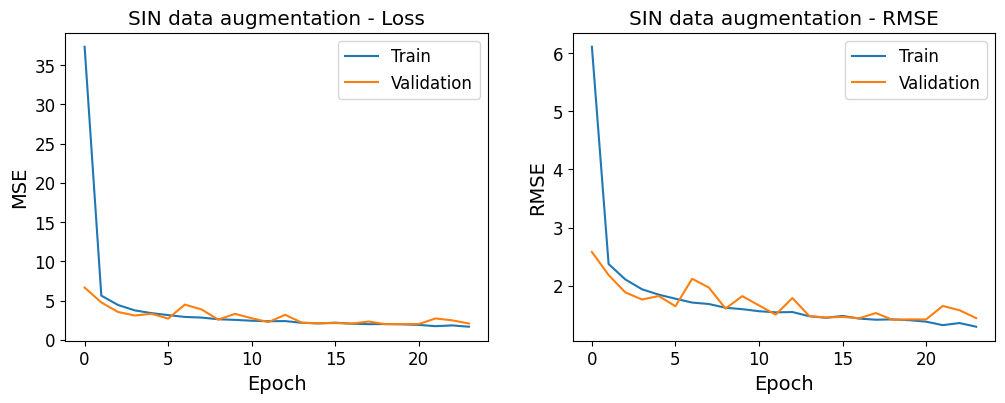

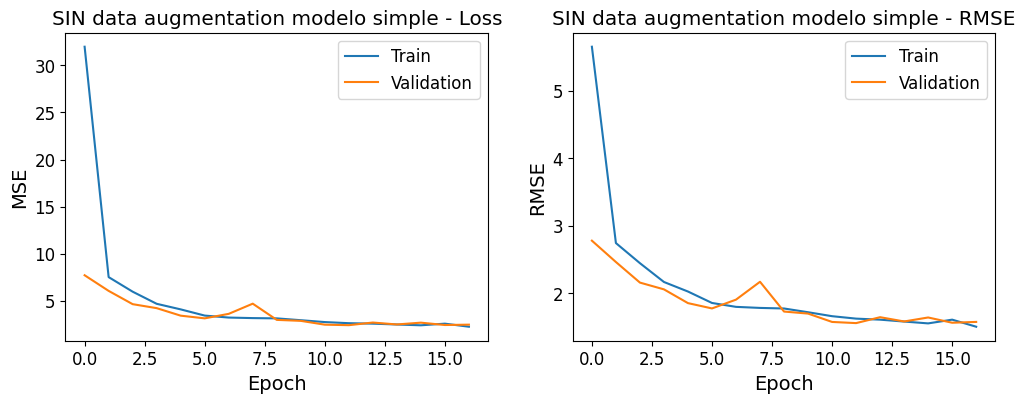

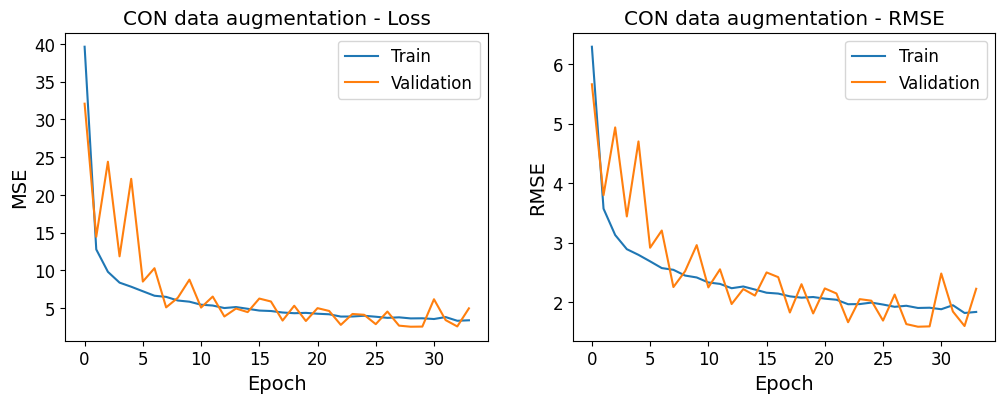

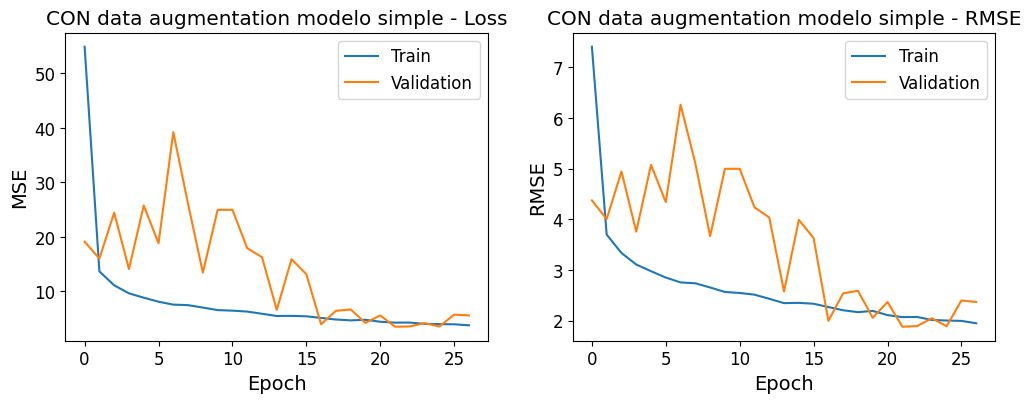

In [61]:
plot_learning_curves(history_normal_no_aug, "SIN data augmentation")
plot_learning_curves(history_simple_no_aug, "SIN data augmentation modelo simple")
plot_learning_curves(history_normal_aug, "CON data augmentation")
plot_learning_curves(history_simple_aug, "CON data augmentation modelo simple")

In [62]:
mean_train = y_train.mean()
y_val_random = np.full_like(y_val, mean_train)

rmse_random = np.sqrt(np.mean((y_val - y_val_random)**2))
print("RMSE modelo aleatorio:", rmse_random)

best_rmse_no_aug = min(history_normal_no_aug.history['val_root_mean_squared_error'])
best_rmse_no_aug_s = min(history_simple_no_aug.history['val_root_mean_squared_error'])
best_rmse_aug = min(history_normal_aug.history['val_root_mean_squared_error'])
best_rmse_aug_s = min(history_simple_aug.history['val_root_mean_squared_error'])

print("RMSE sin aug:", best_rmse_no_aug)
print("RMSE sin aug (modelo simple):", best_rmse_no_aug_s)
print("RMSE con aug:", best_rmse_aug)
print("RMSE con aug (modelo simple):", best_rmse_aug_s)


RMSE modelo aleatorio: 8.71798298697073
RMSE sin aug: 1.4122207164764404
RMSE sin aug (modelo simple): 1.5555418729782104
RMSE con aug: 1.5897718667984009
RMSE con aug (modelo simple): 1.878049612045288


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


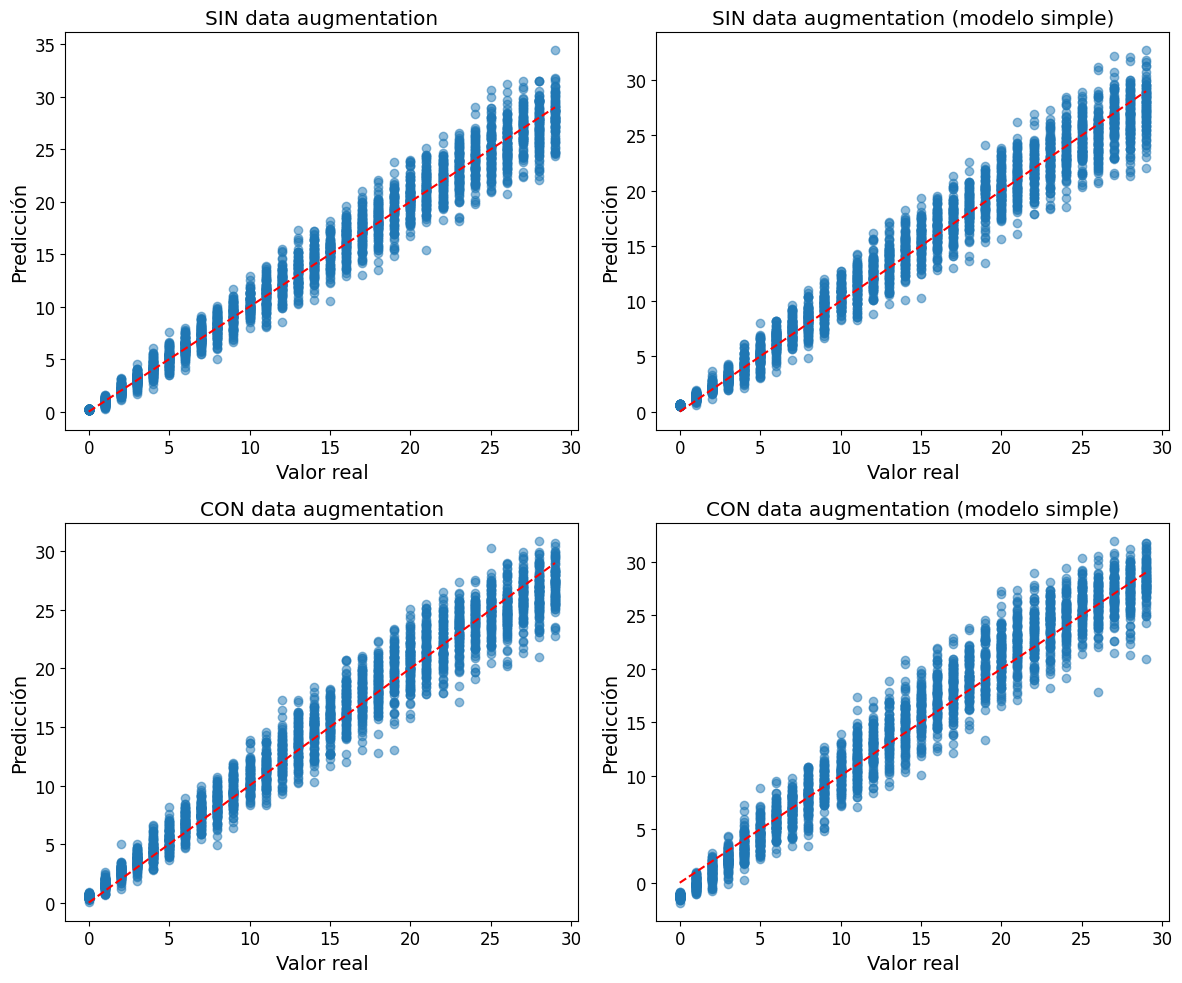

In [63]:
# Predicciones de cada modelo
y_val_pred_normal_no_aug = modelo_normal_no_aug.predict(X_val).flatten()
y_val_pred_simple_no_aug = modelo_simple_no_aug.predict(X_val).flatten()
y_val_pred_normal_aug = modelo_normal_aug.predict(X_val).flatten()
y_val_pred_simple_aug = modelo_simple_aug.predict(X_val).flatten()

plt.figure(figsize=(12,10))

# Modelo sin data augmentation
plt.subplot(2,2,1)
plt.scatter(y_val, y_val_pred_normal_no_aug, alpha=0.5)
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()],
         'r--')
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("SIN data augmentation")

# Modelo sin data augmentation (modelo simple)
plt.subplot(2,2,2)
plt.scatter(y_val, y_val_pred_simple_no_aug, alpha=0.5)
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()],
         'r--')
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("SIN data augmentation (modelo simple)")

# Modelo con data augmentation
plt.subplot(2,2,3)
plt.scatter(y_val, y_val_pred_normal_aug, alpha=0.5)
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()],
         'r--')
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("CON data augmentation")

# Modelo con data augmentation (modelo simple)
plt.subplot(2,2,4)
plt.scatter(y_val, y_val_pred_simple_aug, alpha=0.5)
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()],
         'r--')
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("CON data augmentation (modelo simple)")

plt.tight_layout()
plt.show()


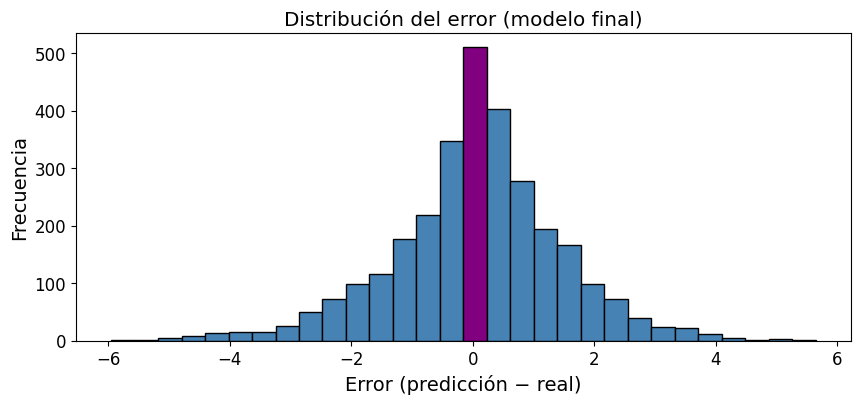

In [64]:
errors = y_val_pred_normal_no_aug - y_val

plt.figure(figsize=(10,4))

counts, bins, patches = plt.hist(errors, bins=30, edgecolor='black')

# Colorear de forma distinta el bin que contiene el 0
for patch, left, right in zip(patches, bins[:-1], bins[1:]):
    if left <= 0 <= right:
        patch.set_facecolor('purple')   # color para error 0
    else:
        patch.set_facecolor('steelblue')

plt.xlabel("Error (predicción − real)")
plt.ylabel("Frecuencia")
plt.title("Distribución del error (modelo final)")
plt.show()


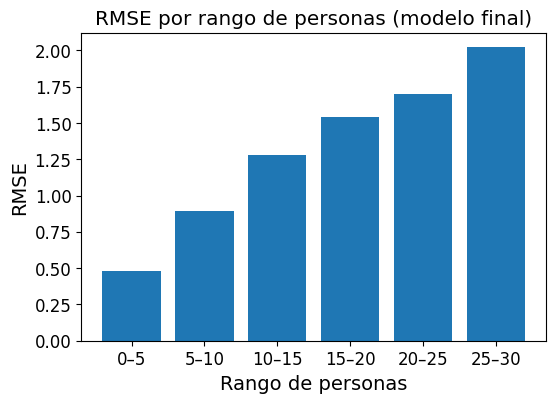

In [65]:
def plot_rmse_by_range(y_true, y_pred, bins, title):
    rmse_bins = []
    labels = []

    for i in range(len(bins) - 1):
        mask = (y_true >= bins[i]) & (y_true < bins[i+1])
        
        if np.sum(mask) > 0:
            rmse = np.sqrt(np.mean((y_true[mask] - y_pred[mask])**2))
            rmse_bins.append(rmse)
        else:
            rmse_bins.append(np.nan)  # bin vacío
        
        labels.append(f"{bins[i]}–{bins[i+1]}")

    plt.figure(figsize=(6,4))
    plt.bar(range(len(rmse_bins)), rmse_bins)
    plt.xticks(range(len(rmse_bins)), labels)
    plt.ylabel("RMSE")
    plt.xlabel("Rango de personas")
    plt.title(title)
    plt.ylim(bottom=0)
    plt.show()

bins = [0, 5, 10, 15, 20, 25, 30]

plot_rmse_by_range(
    y_val,
    y_val_pred_normal_no_aug,
    bins,
    title="RMSE por rango de personas (modelo final)"
)


# Conclusiones de los resultados

Se han evaluado cuatro configuraciones distintas del modelo: arquitectura normal y arquitectura simplificada, ambas entrenadas con y sin aumento de datos. Como referencia adicional, se incluye un modelo aleatorio, que permite establecer una línea base mínima de rendimiento.

Los valores de RMSE obtenidos son los siguientes:

- Modelo aleatorio: 8.72
- Modelo sin data augmentation: 1.41
- Modelo sin data augmentation (modelo simple): 1.56
- Modelo con data augmentation: 1.59
- Modelo con data augmentation (modelo simple): 1.88

#### Origen y sentido del modelo aleatorio

El modelo aleatorio se construye prediciendo siempre el valor medio del conjunto de entrenamiento para todas las imágenes de validación. Es decir, no utiliza ninguna información visual, sino que actúa como un predictor constante. Su RMSE sirve como referencia para comprobar que el modelo entrenado realmente aprende patrones relevantes y no produce resultados triviales. El hecho de que todos los modelos entrenados obtengan un RMSE muy inferior al del modelo aleatorio indica que la red neuronal está capturando información significativa de las imágenes.

## Sobre el entrenamiento

El modelo normal sin data augmentation obtiene el mejor resultado, con un RMSE de 1.41. Esto se explica por las características del dataset: todas las imágenes comparten un encuadre fijo y un fondo muy similar, y la principal variación entre ellas es el número de personas presentes. En este contexto, el modelo puede aprender correlaciones visuales muy estables entre la imagen y el conteo de personas, lo que favorece un buen rendimiento en validación. Además, la arquitectura tiene la capacidad suficiente para modelar esta relación sin necesidad de regularización adicional.

El modelo simplificado sin data augmentation obtiene un RMSE ligeramente peor (1.56), lo que indica que la reducción de complejidad tiene un impacto moderado en el rendimiento. Aun así, el resultado sigue siendo competitivo, lo que demuestra que gran parte de la información relevante puede capturarse con una arquitectura más sencilla. Esta comparación permite justificar que el aumento de complejidad del modelo normal aporta una mejora real, aunque no drástica.

Los modelos entrenados con data augmentation presentan un rendimiento inferior y curvas de validación con picos pronunciados. Esto se debe a que el aumento de datos introduce transformaciones (desplazamientos, zooms, etc.) que no están presentes en el conjunto de validación. Como resultado, el modelo se enfrenta a un problema más difícil durante el entrenamiento y tarda más en ajustarse a la distribución real de los datos de validación. Estos cambios generan una mayor variabilidad en el error de validación, visible como picos en las curvas de RMSE. En el caso del modelo simple con data augmentation, esta dificultad se ve amplificada por la menor capacidad del modelo, lo que provoca un claro infraajuste y un RMSE significativamente mayor.

En conjunto, los resultados muestran que el modelo normal sin data augmentation ofrece el mejor equilibrio entre simplicidad y rendimiento para este problema concreto. El data augmentation, aunque suele ser beneficioso en muchos contextos, introduce en este caso una regularización excesiva debido a la homogeneidad de las imágenes, empeorando el rendimiento. La comparación entre modelos normales y simplificados permite además justificar la arquitectura final elegida y demuestra que la complejidad adicional del modelo no es arbitraria, sino que contribuye a mejorar la métrica de evaluación.

## Sobre el data augmentation

Aunque el data augmentation suele ser una técnica efectiva para mejorar la generalización de modelos de visión por computador, en este problema concreto no ha producido una mejora en el rendimiento. Esto se debe a que el conjunto de datos presenta un encuadre fijo y un fondo prácticamente idéntico en todas las imágenes, siendo la principal fuente de variación el número de personas presentes. Las transformaciones introducidas mediante el aumento de datos generan imágenes que no se corresponden con la distribución real del conjunto de validación, introduciendo una dificultad artificial durante el entrenamiento. Como consecuencia, el modelo aprende de forma menos estable, aparecen picos en el error de validación y el RMSE final empeora, especialmente en arquitecturas con menor capacidad.


## Sobre los gráficos de predicción

Los gráficos de predicción frente al valor real muestran que, en los modelos sin data augmentation, las predicciones se alinean claramente con la recta ideal, lo que indica una buena capacidad del modelo para estimar el número de personas en todo el rango de valores. En el modelo simplificado sin augmentation se observa una mayor dispersión, especialmente para valores altos, lo que explica el ligero empeoramiento del RMSE. En los modelos entrenados con data augmentation, la dispersión aumenta, especialmente en el modelo simple, reflejando una menor capacidad de ajuste y una mayor variabilidad en las predicciones.

El histograma de la distribución del error del modelo final muestra una distribución aproximadamente centrada en cero, lo que indica ausencia de sesgo sistemático en las predicciones. La mayor concentración de errores alrededor del valor cero confirma que el modelo suele cometer errores pequeños, mientras que los errores grandes son poco frecuentes. Este comportamiento es coherente con el bajo RMSE obtenido y refuerza la conclusión de que el modelo final generaliza correctamente sobre el conjunto de validación.


# Conclusión final

En este trabajo se ha desarrollado y evaluado una red neuronal convolucional sencilla para el conteo de personas en imágenes, comparando distintas arquitecturas y estrategias de entrenamiento. Los resultados muestran que un modelo compacto, entrenado sin data augmentation, ofrece el mejor equilibrio entre simplicidad y rendimiento, obteniendo un RMSE claramente inferior al de un modelo aleatorio y a las versiones entrenadas con aumento de datos. La comparación con un modelo simplificado permite comprobar que la reducción de complejidad conlleva una ligera pérdida de rendimiento, lo que justifica la arquitectura final elegida. En conjunto, el análisis confirma que, para este conjunto de datos concreto, un modelo simple pero bien ajustado es suficiente para capturar los patrones relevantes sin necesidad de técnicas de regularización adicionales.

# Descargar datos de test


In [48]:
test_dir = '/kaggle/input/ml-ub-project-4-learning-to-count-2025-26/test/'
im_size = 64
N = 500

X_test = np.zeros((N, im_size, im_size, 1))

for i in range(N):
    im = imageio.imread(test_dir + 'test_composite' + str(i).zfill(9) + '.png')
    small_im = transform.resize(im, (im_size, im_size))
    X_test[i, :, :, 0] = small_im


# Usar modelo con test y crear el csv a entregar

In [50]:
# VERSION MODELO SIN DATA AUG

y_test = modelo_normal_no_aug.predict(X_test)
y_test = np.clip(y_test, 0, None)   # no personas negativas
y_test = y_test.astype(int)

df_output = pd.DataFrame({
    'prediction': y_test.flatten()
})

df_output.index.name = 'index'
df_output.to_csv('submission.csv')

print("Archivo creado!")

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Archivo creado!
